# HW1: COVID-19 Daily Cases Prediction - DNN

This notebook trains a deeper PyTorch neural network to predict `tested_positive` from the provided COVID-19 survey features. The evaluation metric is Mean Squared Error (MSE).

## Download the Dataset

Uncomment and run the following commands if the training and testing CSV files are not already available.

In [130]:
# !pip install gdown
# !gdown 1BjXalPZxq9mybPKNjF3h5L3NcF7XKTS- --output covid_train.csv
# !gdown 1B55t74Jg2E5FCsKCsUEkPKIuqaY7UIi1 --output covid_test.csv

## Setup and Model Overview

### Main Packages

- `torch`: model definition, tensor operations, optimization, and data loading.
- `numpy`: numerical preprocessing.
- `pandas`: CSV data loading and submission export.
- `matplotlib`: training and validation loss visualization.
- `tqdm`: training progress bars.
- `dataclasses`, `pathlib`, and `random`: configuration, file discovery, and reproducibility.

### Model

- Name: Deep Neural Network Regressor.
- Input size: 16 normalized features selected by correlation with the next-day target.
- Parameter count: 46,561 trainable parameters.
- Structure: `Linear(16, 256) -> ReLU -> Linear(256, 128) -> ReLU -> Linear(128, 64) -> ReLU -> Linear(64, 16) -> ReLU -> Linear(16, 1)`.
- Training configuration: batch size `64`, learning rate `1e-3`, weight decay `0.0`, maximum epochs `1000`, and early stopping patience `200`.
- Strategy: predict the final training column (`tested_positive.2`) from the feature columns available in the test set, matching the official homework data layout.
- Output: one continuous next-day prediction exported as `tested_positive`.

In [131]:
from dataclasses import asdict, dataclass
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, random_split
from tqdm.auto import tqdm

try:
    import wandb
except ImportError:
    wandb = None

@dataclass(frozen=True)
class Config:
    seed: int = 42
    validation_ratio: float = 0.2
    batch_size: int = 64
    selected_feature_count: int = 16
    hidden_dims: tuple[int, ...] = (256, 128, 64, 16)
    dropout_rates: tuple[float, ...] = (0.0, 0.0, 0.0, 0.0)
    learning_rate: float = 1e-3
    weight_decay: float = 0.0
    scheduler_factor: float = 0.5
    scheduler_patience: int = 8
    max_epochs: int = 1000
    early_stopping_patience: int = 200
    model_filename: str = "dnn_model.pt"
    submission_filename: str = "submission_dnn.csv"
    num_workers: int = 0
    gpu_id: int = 0
    use_wandb: bool = False
    wandb_project: str = "hung-yi-lee-machine-learning"
    wandb_run_name: str = "hw1-dnn-regression"

CONFIG = Config()

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def choose_device() -> torch.device:
    if torch.cuda.is_available():
        gpu_count = torch.cuda.device_count()
        gpu_id = CONFIG.gpu_id if 0 <= CONFIG.gpu_id < gpu_count else 0
        if gpu_id != CONFIG.gpu_id:
            print(f"Requested CUDA GPU {CONFIG.gpu_id}, but only {gpu_count} GPU(s) are available. Falling back to cuda:0.")
        if hasattr(torch, "set_float32_matmul_precision"):
            torch.set_float32_matmul_precision("high")
        torch.backends.cudnn.benchmark = True
        device = torch.device(f"cuda:{gpu_id}")
        torch.cuda.set_device(device)
        print(f"Using CUDA GPU {gpu_id}: {torch.cuda.get_device_name(gpu_id)}")
        return device

    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        print("Using Apple Metal Performance Shaders (MPS).")
        return torch.device("mps")

    print("Using CPU. GPU acceleration is not available in this environment.")
    return torch.device("cpu")


def to_device(tensor: torch.Tensor) -> torch.Tensor:
    return tensor.to(device, non_blocking=(device.type == "cuda"))


def dataloader_kwargs(shuffle: bool = False) -> dict:
    return {
        "batch_size": CONFIG.batch_size,
        "shuffle": shuffle,
        "num_workers": CONFIG.num_workers,
        "pin_memory": device.type == "cuda",
    }


def init_wandb():
    if not CONFIG.use_wandb:
        return None
    if wandb is None:
        raise ImportError("Install wandb or set CONFIG.use_wandb=False.")
    return wandb.init(
        project=CONFIG.wandb_project,
        name=CONFIG.wandb_run_name,
        config=asdict(CONFIG),
    )


set_seed(CONFIG.seed)
device = choose_device()
wandb_run = init_wandb()
print(f"Using device: {device}")
print(CONFIG)

Using device: mps
Config(seed=42, validation_ratio=0.2, batch_size=64, selected_feature_count=16, hidden_dims=(256, 128, 64, 16), dropout_rates=(0.0, 0.0, 0.0, 0.0), learning_rate=0.001, weight_decay=0.0, scheduler_factor=0.5, scheduler_patience=8, max_epochs=1000, early_stopping_patience=200, model_filename='dnn_model.pt', submission_filename='submission_dnn.csv')


## Load the dataset

In [132]:
def find_data_dir() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd() / "HW1",
        Path.cwd() / "machine-learning" / "hung-yi-lee-machine-learning" / "HW1",
    ]
    for candidate in candidates:
        if (candidate / "covid_train.csv").exists() and (candidate / "covid_test.csv").exists():
            return candidate
    raise FileNotFoundError("Place covid_train.csv and covid_test.csv next to this notebook or run from the repository root.")

DATA_DIR = find_data_dir()
train_df = pd.read_csv(DATA_DIR / "covid_train.csv")
test_df = pd.read_csv(DATA_DIR / "covid_test.csv")

print(f"Data directory: {DATA_DIR.resolve()}")
print(f"Training samples: {len(train_df)}, columns: {len(train_df.columns)}")
print(f"Testing samples:  {len(test_df)}, columns: {len(test_df.columns)}")
train_df.head()

Data directory: /Users/chenzanxin/Documents/CS Learning/machine-learning/hung-yi-lee-machine-learning/HW1
Training samples: 3009, columns: 89
Testing samples:  997, columns: 88


,id,AL,AZ,CA,CO,CT,FL,GA,IL,IN,...,wothers_distanced_public.2,wshop_indoors.2,wrestaurant_indoors.2,wworried_catch_covid.2,hh_cmnty_cli.2,nohh_cmnty_cli.2,wearing_mask_7d.2,public_transit.2,worried_finances.2,tested_positive.2
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,19.271113,69.050180,38.102142,47.130223,22.686202,17.583283,62.925033,2.704414,39.222329,18.490787
1,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,19.500509,68.847156,37.338682,46.598421,22.484758,17.219515,62.771641,2.474973,41.209073,16.329253
2,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,18.938706,68.694620,37.543537,46.858400,22.506261,17.128204,62.546116,2.569940,39.636816,16.522931
3,3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,18.698535,69.339191,37.751874,44.633652,22.369951,17.069263,61.517466,2.610086,38.926817,15.578501
4,4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,18.034980,69.564435,38.341833,44.100299,21.440588,16.207377,60.933647,2.790749,39.840306,14.171920


In [133]:
SUBMISSION_TARGET = "tested_positive"
ID_COLUMN = "id"
TARGET = train_df.columns[-1]
candidate_feature_columns = list(test_df.columns)
feature_correlations = train_df[candidate_feature_columns].corrwith(train_df[TARGET]).abs()
feature_columns = feature_correlations.nlargest(CONFIG.selected_feature_count).index.tolist()

assert TARGET == "tested_positive.2"
assert len(train_df) == 3009
assert len(test_df) == 997
assert set(feature_columns).issubset(train_df.columns)

print(f"Prediction target: {TARGET}")
print(f"Selected features ({len(feature_columns)}): {feature_columns}")
train_df[TARGET].describe()

Prediction target: tested_positive.2
Selected features (16): ['tested_positive.1', 'tested_positive', 'hh_cmnty_cli', 'nohh_cmnty_cli', 'hh_cmnty_cli.1', 'wnohh_cmnty_cli', 'nohh_cmnty_cli.1', 'wnohh_cmnty_cli.1', 'hh_cmnty_cli.2', 'nohh_cmnty_cli.2', 'wnohh_cmnty_cli.2', 'ili', 'cli', 'cli.1', 'ili.1', 'cli.2']


count    3009.000000
mean       17.305063
std         9.914877
min         3.054288
25%         9.101412
50%        14.848052
75%        23.361068
max        46.952473
Name: tested_positive.2, dtype: float64

## Prepare tensors and data loaders

In [134]:
class CovidDataset(Dataset):
    def __init__(self, features: torch.Tensor, targets: torch.Tensor | None = None) -> None:
        self.features = features
        self.targets = targets

    def __len__(self) -> int:
        return len(self.features)

    def __getitem__(self, index: int):
        if self.targets is None:
            return self.features[index]
        return self.features[index], self.targets[index]

train_features = train_df[feature_columns].to_numpy(dtype=np.float32)
test_features = test_df[feature_columns].to_numpy(dtype=np.float32)
train_targets = train_df[TARGET].to_numpy(dtype=np.float32).reshape(-1, 1)

# Fit normalization statistics on the training data only.
feature_mean = train_features.mean(axis=0, keepdims=True)
feature_std = train_features.std(axis=0, keepdims=True)
feature_std[feature_std < 1e-8] = 1.0

train_features = (train_features - feature_mean) / feature_std
test_features = (test_features - feature_mean) / feature_std

full_dataset = CovidDataset(
    torch.from_numpy(train_features),
    torch.from_numpy(train_targets),
)
test_dataset = CovidDataset(torch.from_numpy(test_features))

validation_size = int(CONFIG.validation_ratio * len(full_dataset))
training_size = len(full_dataset) - validation_size
training_dataset, validation_dataset = random_split(
    full_dataset,
    [training_size, validation_size],
    generator=torch.Generator().manual_seed(CONFIG.seed),
)

training_loader = DataLoader(training_dataset, **dataloader_kwargs(shuffle=True))
validation_loader = DataLoader(validation_dataset, **dataloader_kwargs())
test_loader = DataLoader(test_dataset, **dataloader_kwargs())

print(f"Training split:   {len(training_dataset)}")
print(f"Validation split: {len(validation_dataset)}")

Training split:   2408
Validation split: 601


## Build and train the regression model

In [135]:
class RegressionModel(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: tuple[int, ...], dropout_rates: tuple[float, ...]) -> None:
        super().__init__()
        assert len(hidden_dims) == len(dropout_rates)
        layers = []
        previous_dim = input_dim
        for hidden_dim, dropout_rate in zip(hidden_dims, dropout_rates):
            layers.extend([nn.Linear(previous_dim, hidden_dim), nn.ReLU()])
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            previous_dim = hidden_dim
        layers.append(nn.Linear(previous_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.network(features)

model = RegressionModel(
    input_dim=len(feature_columns),
    hidden_dims=CONFIG.hidden_dims,
    dropout_rates=CONFIG.dropout_rates,
).to(device)
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CONFIG.learning_rate,
    weight_decay=CONFIG.weight_decay,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    factor=CONFIG.scheduler_factor,
    patience=CONFIG.scheduler_patience,
)

print(f"Trainable parameters: {sum(parameter.numel() for parameter in model.parameters()):,}")
if wandb_run is not None:
    wandb.watch(model, log="gradients", log_freq=100)
model

Trainable parameters: 46,561


RegressionModel(
  (network): Sequential(
    (0): Linear(in_features=16, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [136]:
def evaluate(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for features, targets in loader:
            features = to_device(features)
            targets = to_device(targets)
            predictions = model(features)
            total_loss += loss_function(predictions, targets).item() * len(features)
    return total_loss / len(loader.dataset)

checkpoint_path = DATA_DIR / CONFIG.model_filename
best_validation_loss = float("inf")
epochs_without_improvement = 0
training_losses = []
validation_losses = []

epoch_progress = tqdm(range(1, CONFIG.max_epochs + 1), desc="Training", unit="epoch")
for epoch in epoch_progress:
    model.train()
    total_training_loss = 0.0

    for features, targets in training_loader:
        features = to_device(features)
        targets = to_device(targets)

        optimizer.zero_grad()
        predictions = model(features)
        loss = loss_function(predictions, targets)
        loss.backward()
        optimizer.step()

        total_training_loss += loss.item() * len(features)

    training_loss = total_training_loss / len(training_loader.dataset)
    validation_loss = evaluate(model, validation_loader)
    scheduler.step(validation_loss)
    training_losses.append(training_loss)
    validation_losses.append(validation_loss)

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "input_dim": len(feature_columns),
                "config": asdict(CONFIG),
                "validation_mse": best_validation_loss,
            },
            checkpoint_path,
        )
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if wandb_run is not None:
        wandb.log({
            "epoch": epoch,
            "train/mse": training_loss,
            "valid/mse": validation_loss,
            "learning_rate": optimizer.param_groups[0]["lr"],
        })

    epoch_progress.set_postfix(train_mse=f"{training_loss:.4f}", val_mse=f"{validation_loss:.4f}")

    if epochs_without_improvement >= CONFIG.early_stopping_patience:
        print(f"Early stopping at epoch {epoch}.")
        break

checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
checkpoint_training_mse = evaluate(model, training_loader)
print(f"Checkpoint training MSE: {checkpoint_training_mse:.4f}")
print(f"Best validation MSE: {checkpoint['validation_mse']:.4f}")
print(f"Saved model to: {checkpoint_path.resolve()}")
if wandb_run is not None:
    wandb.summary["checkpoint_training_mse"] = checkpoint_training_mse
    wandb.summary["best_validation_mse"] = checkpoint["validation_mse"]
    wandb.finish()

Training:   0%|          | 0/1000 [00:00<?, ?epoch/s]

Early stopping at epoch 302.
Checkpoint training MSE: 0.8419
Best validation MSE: 0.8160
Saved model to: /Users/chenzanxin/Documents/CS Learning/machine-learning/hung-yi-lee-machine-learning/HW1/dnn_model.pt


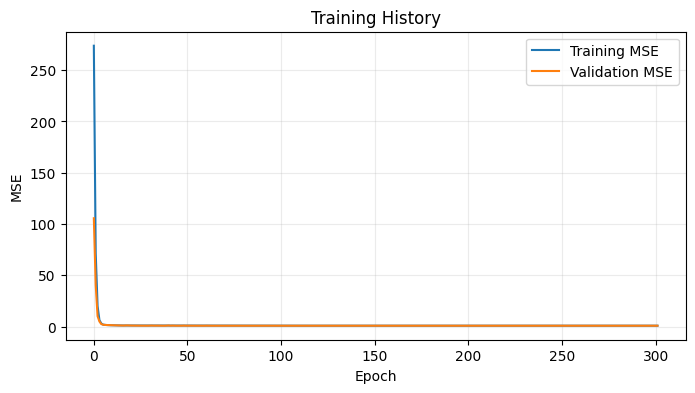

In [137]:
plt.figure(figsize=(8, 4))
plt.plot(training_losses, label="Training MSE")
plt.plot(validation_losses, label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training History")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## Predict the test set and export the submission

In [138]:
def predict(model: nn.Module, loader: DataLoader) -> np.ndarray:
    model.eval()
    predictions = []
    with torch.no_grad():
        for features in loader:
            batch_predictions = model(to_device(features))
            predictions.append(batch_predictions.cpu().numpy())
    return np.concatenate(predictions).reshape(-1)

test_predictions = predict(model, test_loader)
submission = pd.DataFrame({
    ID_COLUMN: test_df[ID_COLUMN],
    SUBMISSION_TARGET: test_predictions,
})

submission_path = DATA_DIR / CONFIG.submission_filename
submission.to_csv(submission_path, index=False)
print(f"Saved submission to: {submission_path.resolve()}")
submission.head()

Saved submission to: /Users/chenzanxin/Documents/CS Learning/machine-learning/hung-yi-lee-machine-learning/HW1/submission_dnn.csv


,id,tested_positive
0,0,32.420486
1,1,6.007892
2,2,25.054268
3,3,26.846209
4,4,40.261658
